In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv("seeds_data.csv")
df.head(3)

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1


In [4]:
X = df.drop(columns=["Class"]).values
y_true = df["Class"].values

In [5]:
# Feature Scaling
X = (X - X.mean(axis=0)) / X.std(axis=0)

In [6]:
class KMeansScratch:
    def __init__(self, k, max_iter=100, tol=1e-4):
        self.k = k
        self.max_iter = max_iter
        self.tol = tol
        
    def fit(self, X):
        n, d = X.shape

        idx = np.random.choice(n, self.k, replace=False)
        self.centroids = X[idx]

        for _ in range(self.max_iter):
            distances = np.linalg.norm(X[:,None] - self.centroids[None,:], axis=2)
            labels = np.argmin(distances, axis=1)
            
            new_centroids = np.array([
                X[labels == i].mean(axis=0) if np.any(labels==i) else self.centroids[i]
                for i in range(self.k)
            ])
            
            if np.linalg.norm(self.centroids - new_centroids) < self.tol:
                break
                
            self.centroids = new_centroids

        self.labels = labels
        return labels

In [7]:
def dunn_index(X, labels):
    clusters = [X[labels == i] for i in np.unique(labels)]

    intra = max([np.max(np.linalg.norm(c[:,None]-c[None,:],axis=2)) for c in clusters])

    inter = []
    for i in range(len(clusters)):
        for j in range(i+1,len(clusters)):
            dist = np.min(np.linalg.norm(clusters[i][:,None]-clusters[j][None,:],axis=2))
            inter.append(dist)
    return np.min(inter) / intra

In [8]:
k_vals = range(2,8)
dunn_scores = []

In [9]:
for k in k_vals:
    km = KMeansScratch(k)
    labels = km.fit(X)
    dunn_scores.append(dunn_index(X,labels))

In [10]:
best_k = k_vals[np.argmax(dunn_scores)]
print("Best k:",best_k)

Best k: 2


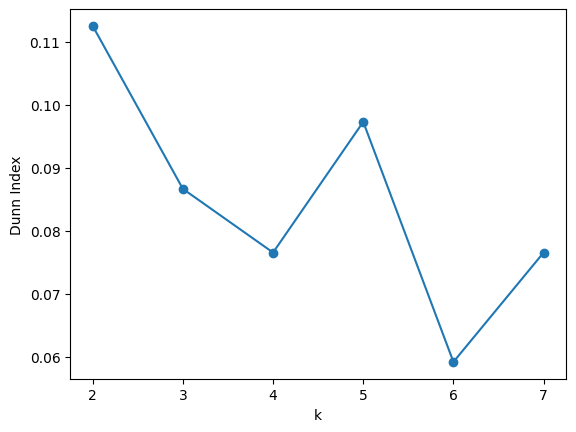

In [11]:
# Plotting graph...
plt.plot(k_vals,dunn_scores,marker='o')
plt.xlabel("k")
plt.ylabel("Dunn Index")
plt.show()

In [12]:
kmeans = KMeansScratch(best_k)
labels = kmeans.fit(X)

print("Cluster Centers:\n", kmeans.centroids)

Cluster Centers:
 [[-0.68228912 -0.68357556 -0.35412424 -0.65951457 -0.64779184  0.09994527
  -0.67159051]
 [ 1.10871981  1.11081029  0.57545189  1.07171117  1.05266175 -0.16241106
   1.09133458]]


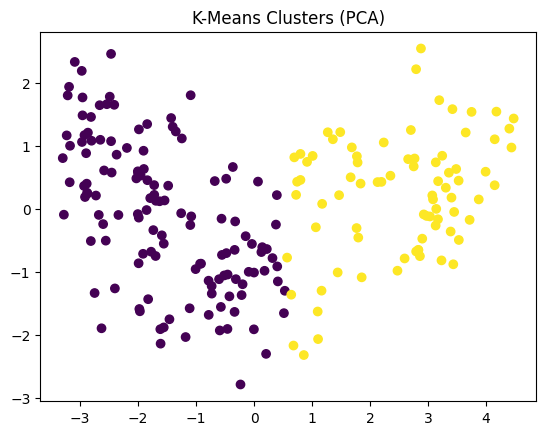

In [13]:
pca = PCA(2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0],X_pca[:,1],c=labels,cmap='viridis')
plt.title("K-Means Clusters (PCA)")
plt.show()

In [14]:
def comb2(n):
    return n*(n-1)//2

def adjusted_rand(true,pred):
    table = pd.crosstab(true,pred).values
    N = len(true)
    
    sum_ij = sum(comb2(n) for n in table.flatten())
    sum_row = sum(comb2(n) for n in table.sum(axis=1))
    sum_col = sum(comb2(n) for n in table.sum(axis=0))
    total = comb2(N)
    
    expected = sum_row*sum_col/total
    max_ind = 0.5*(sum_row+sum_col)
    
    return (sum_ij - expected)/(max_ind - expected)
    
print("ARI:", adjusted_rand(y_true,labels)*100,"%")

ARI: 50.747675564505755 %
